In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('Datasets/D25/wine_data.csv',usecols = [0,1,2])
df.columns = ['Class Label','Alcohol','Malic Acid']

In [13]:
df.sample(5)

,Class Label,Alcohol,Malic Acid
136,3,12.53,5.51
71,2,13.49,1.66
158,3,13.48,1.67
11,1,13.75,1.73
94,2,12.47,1.52


<Axes: xlabel='Alcohol', ylabel='Density'>

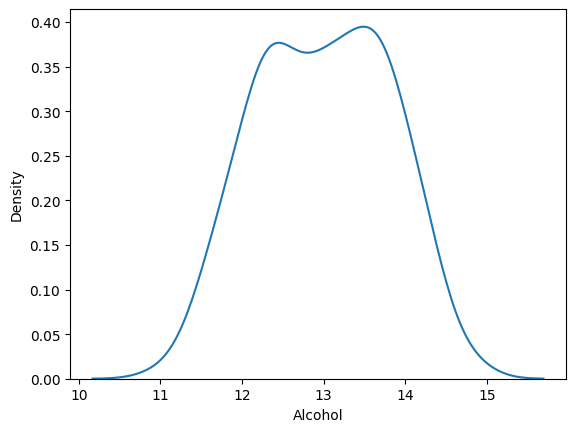

In [14]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

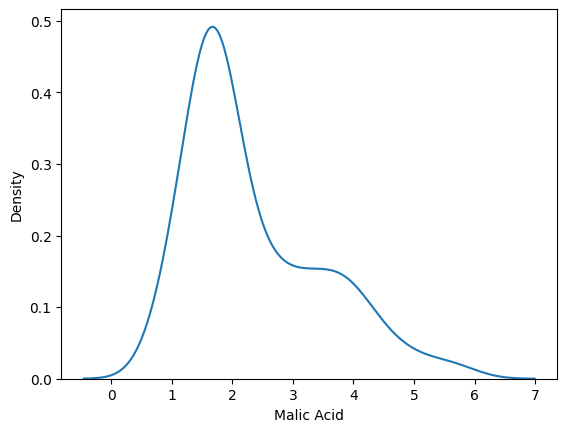

In [15]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

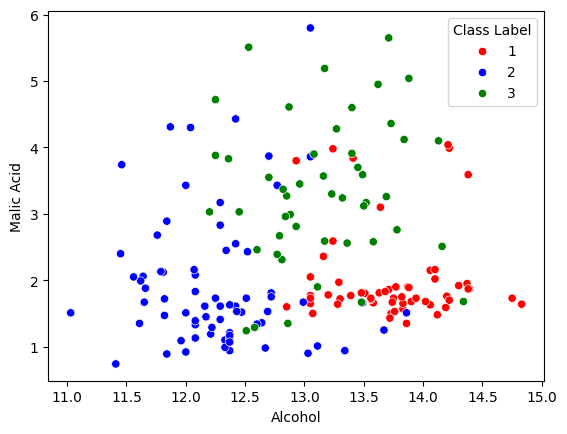

In [20]:
color_dict = {1:'red',2:'blue',3:'green'}
sns.scatterplot(data = df,x = 'Alcohol',y = 'Malic Acid',hue = 'Class Label',palette = color_dict)

## Min Max Scalling :
# Xi = (Xi- Xmin)/(Xmax - Xmin) [0 to 1]

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,1:],df['Class Label'],test_size = 0.3,random_state = 0)

In [23]:
X_train.shape , X_test.shape

((123, 2), (54, 2))

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [32]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns = X_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns = X_test.columns)

In [35]:
x_train_scaled.describe()

,Alcohol,Malic Acid
count,123.000000,123.000000
mean,0.523079,0.293676
std,0.209894,0.237984
min,0.000000,0.000000
25%,0.360215,0.136456
50%,0.543011,0.191446
75%,0.697581,0.445010
max,1.000000,1.000000


In [36]:
X_train.describe()

,Alcohol,Malic Acid
count,123.000000,123.000000
mean,12.975854,2.331951
std,0.780806,1.168503
min,11.030000,0.890000
25%,12.370000,1.560000
50%,13.050000,1.830000
75%,13.625000,3.075000
max,14.750000,5.800000


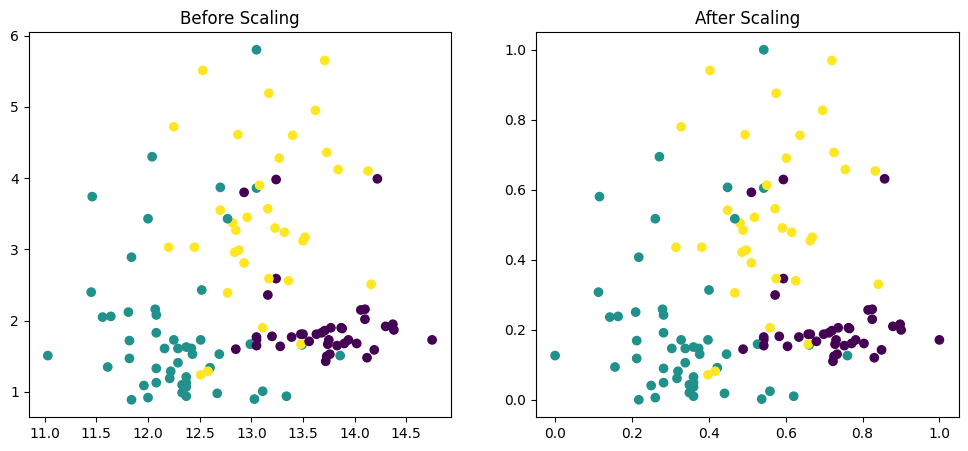

In [39]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic Acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic Acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

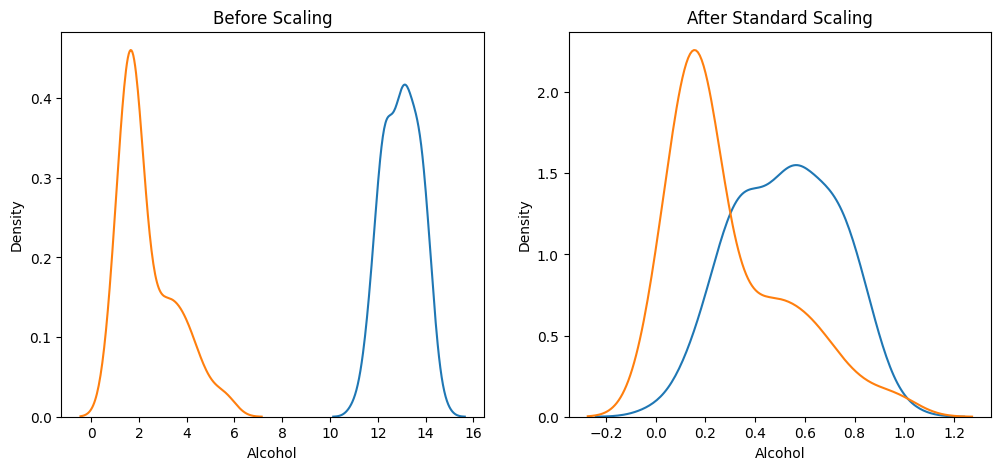

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic Acid'], ax=ax2)
plt.show()

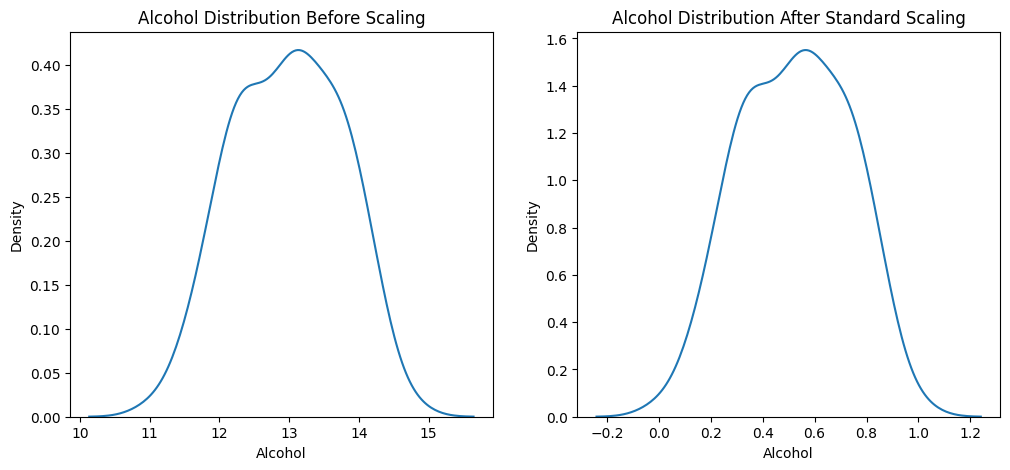

In [42]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
plt.show()

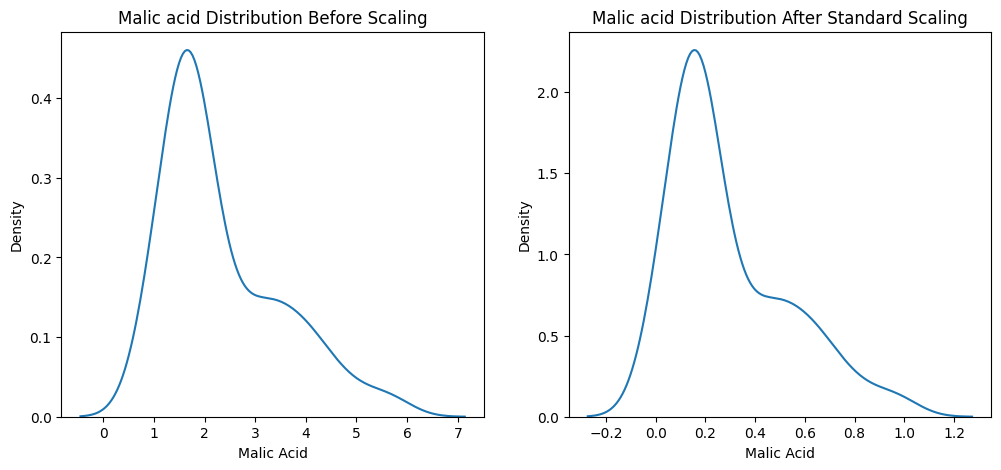

In [43]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Malic Acid'], ax=ax2)
plt.show()

## Mean Normalization:

# Xi' = (Xi - Xmean)/Xmax - Xmin  [-1 to 1]

## MaxAbs Scaling
# Xi' = Xi/|Xmax|

## Robust  Scaling

# Xi' = Xi - Xmedian / IQR(Q3 - Q1)  (it is Robust to Outliers )